#LeNet

#Input layer
> * Input size: 32 x 32 pixels

  The input is larger than the largest character in the database, which is at most 20x20 pixels, centered in a 28x28 field. The larger input size ensures that distinctive features such as stroke endpoints or corners can appear in the center of the receptive field of the highest-level feature detectors.

* Normallization :
     Input pixel values are normalized such that the background (white) corresponds to a value of 0, and the foreground (black) corresponds to a value of 1. This normalization makes the mean input roughly 0 and the variance roughly 1, which accelerates the learning process.



## layer C1(Convolutional Layer)
>* Feature maps: 6 feature maps
>* Connections: Ecah unit is connected to a 5x5 neighborhood
  in the input, producing 28x28 feature maps to prevent boundary effects
  > * Parameters: 156 trainable parameters and 117,600 connections



## Layer S2 (Subsmapling layer)
>* Feature maps : 6 feature maps
>* Size: 14x14 (each unit adds four inputs , multiplies by a trainable coefficient, adds a  bias, and applies a sigmiod function.
>* Parameters: 12 trainable parameters and 5880 connections


##Layer C3 (Convolutional layer)
> * **Feature** Maps: 16 feature maps.
> * **Connections**: Each unit is connected to several 5x5 neighborhoods
    at identical locations in a subset of S2’s feature maps.
> * **Parameters and Connections** : Connections are partially connected to force feature maps to learn different
   features, with 1,516 trainable parameters and 151,600 connections.     

   

## Layer S4 (Subsampling Layer)

>* **Feature Maps**: Feature Maps: 16 feature maps.

>* **Size**: 7x7 (each unit connected to a 2x2 neighborhood in C3).

>* **Parameters**: 32 trainable parameters and 2,744 connections.



##Layer C3 (Convolutional Layer)

>* **Feature Maps** : 120 feature maps.
>* **Size**: 1x1 (each unit connected to a 5x5 neighborhood on all 16 of S4’s feature maps, effectively fully connected due to input size).
>* **Parameters**: 48,000 trainable parameters and 48,000 connections.


## Layer F6(Fully Connected Layer)

>* **Units**:  84 units.
>* **Connections**: Each unit is fully connected to C5, resulting in 10,164 trainable parameters.
>* **Activation**: Uses a scaled hyperbolic tangent function f(a)=Atan⁡(Sa)f(a)=Atan(Sa), where A = 1.7159 and S = 2/3

## Output Layer
In the output layer of LeNet, each class is represented by an Euclidean Radial Basis Function (RBF) unit.



##Implementation

In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


###1. Loading the Dataset

In [3]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np


mnist = tf.keras.datasets.mnist
(x_train, y_train) , (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##2. Preprocessing and Normalizing the Data

In [4]:
rows, cols = 28, 28

# Reshape the data into a 4D Array
x_train = x_train.reshape(x_train.shape[0], rows, cols, 1)
x_test = x_test.reshape(x_test.shape[0], rows, cols, 1)

input_shape = (rows,cols,1)

# Set type as float32 and normalize the values to [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train / 255.0
x_test = x_test / 255.0

# Transform labels to one hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)

##3. Define LeNet-5 Model

``It is important to highlight that each image in the MNIST data set has a size of 28 X 28 pixels so we will use the same dimensions for LeNet-5 input instead of 32 X 32 pixels.``

In [9]:
def build_lenet(input_shape):
  # Define Sequential Model
  model = tf.keras.Sequential()

  # C1 Convolutional Layer
  model.add(tf.keras.layers.Conv2D(filters=6,
                                   strides=(1, 1),
                                   kernel_size=(5,5),
                                   activation='tanh',
                                   input_shape=input_shape))

  # S2 Subsamling Layer
  model.add(tf.keras.layers.Conv2D(filters=6,
                                   strides=(1,1),
                                   kernel_size=(5, 5),
                                   activation="tanh"))

  # C3 Convolutional Layer
  model.add(tf.keras.layers.Conv2D(filters=6,
                                   strides=(1,1),
                                   kernel_size=(5,5),
                                   activation="tanh"))

  # S4 Subsampling Layer
  model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2),
                                             strides=(2,2)))

  # C5 Fully connected Layer
  model.add(tf.keras.layers.Dense(units=120, activation='tanh'))

  # Flatten the output so that we can  connect it with the fully connected layrs
  # by converting it into a 1D Array
  model.add(tf.keras.layers.Flatten())

  # FC6 Fully Connnected Layers

  model.add(tf.keras.layers.Dense(units=84, activation='tanh'))

  # Output Layer
  model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

  return model


## Evaluating the model and visualizing the process

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 144ms/step - accuracy: 0.8732 - loss: 0.4252
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 146ms/step - accuracy: 0.9711 - loss: 0.1032
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - accuracy: 0.9829 - loss: 0.0595
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 148ms/step - accuracy: 0.9868 - loss: 0.0457
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - accuracy: 0.9894 - loss: 0.0366
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - accuracy: 0.9912 - loss: 0.0309
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - accuracy: 0.9925 - loss: 0.0250
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - accuracy: 0.9937 - loss: 0.0219
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - accuracy: 0.9950 - loss: 0.0175
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 143ms/step - accuracy: 0.9940 - loss: 0.0200
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9838 - loss: 0.0573
Accuracy :  0.98580002784729
Trai

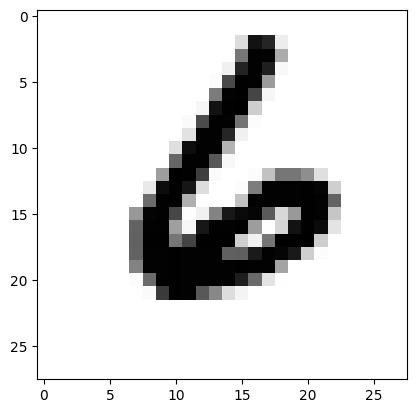

In [10]:
lenet = build_lenet(input_shape)

# Compile the model
lenet.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# # We will be allowing 10 itterations to happen
epochs = 10
history = lenet.fit(x_train, y_train, epochs=epochs,batch_size=128, verbose=1)

# Check the Accuracy of the model
# Transform the labels of one hot encoding

if len(y_test.shape) != 2 or y_test.shape[1] != 10:
  y_test = tf.keras.utils.to_categorical(y_test, 10)


loss ,acc= lenet.evaluate(x_test, y_test)
print('Accuracy : ', acc)


x_train = x_train.reshape(x_train.shape[0], 28,28)
print('Training Data', x_train.shape, y_train.shape)
x_test = x_test.reshape(x_test.shape[0], 28,28)
print('Test Data', x_test.shape, y_test.shape)

# Plot the Image
image_index = 8888
plt.imshow(x_test[image_index].reshape(28,28), cmap="Greys")


# Make Prediction
pred = lenet.predict(x_test[image_index].reshape(1, rows, cols, 1 ))
print(pred.argmax())
